# Tutorial

In [ ]:
!git clone https://github.com/runyao-yu/PriceFM.git
#%cd PriceFM
!pip install -r requirements.txt

Cloning into 'PriceFM'...
remote: Enumerating objects: 268, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 268 (delta 12), reused 38 (delta 8), pack-reused 225 (from 2)
Receiving objects: 100% (268/268), 131.61 MiB | 16.89 MiB/s, done.
Resolving deltas: 100% (39/39), done.
/content/PriceFM
     ÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚ÂÃƒÂ¢Ã¢â‚¬ÂÃ‚Â 60.8/60.8 kB 1.2 MB/s eta 0:00:00
 

# Check the `Google_Colab_Instruction.pdf` for Google Colab

In [1]:
#%cd PriceFM
from PriceFM import *
import pandas as pd
import numpy as np

# 3 folds
train_val_test_splits = [("2022-01-01", "2024-09-01", "2024-09-01", "2025-01-01", "2025-01-01", "2025-05-01"),
                         ("2022-01-01", "2025-01-01", "2025-01-01", "2025-05-01", "2025-05-01", "2025-09-01"),
                         ("2022-01-01", "2025-05-01", "2025-05-01", "2025-09-01", "2025-09-01", "2026-01-01")]

train_start, train_end, val_start, val_end, test_start, test_end = train_val_test_splits[2]

countries = [
    "AT", "BE", "BG", "CZ", "DE_LU", "DK_1", "DK_2",
    "EE", "ES", "FI", "FR", "GR",    "HR", "HU",
    "IT_CALA", "IT_CNOR", "IT_CSUD", "IT_NORD", "IT_SARD", "IT_SICI", "IT_SUD",
    "LT", "LV", "NL", "NO_1", "NO_2", "NO_3", "NO_4", "NO_5",
    "PL", "PT", "RO", "SE_1", "SE_2", "SE_3", "SE_4", "SI", "SK",
]

label_column = "price"
lag_features  = ["price", "load",  "solar", "wind"]
lead_features = ["load",  "solar", "wind"]

#lag_features  = ["price", "load",  "solar", "wind", "generation"]
#lead_features = ["load",  "solar", "wind", "generation"]

features = sorted((set(lag_features) | set(lead_features)) - {label_column})

lag_window      = 96
lead_window     = 96

rolling_train = {}
rolling_val   = {}
rolling_test  = {}

adjacency_dict = graph_adj_matrix()

c:\Users\YuR\AppData\Local\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Data processing

- read data
- split into train, val, test
- scale
- separate by country code
- rolling window to create samples

In [2]:
#!pip install -q huggingface_hub

from huggingface_hub import hf_hub_download

# read df
file_path = hf_hub_download(
    repo_id="RunyaoYu/PriceFM",
    filename="FINAL.csv",
    repo_type="dataset"
)

df = read_dataset(file_path)

In [3]:
# split into train val test
df_train, df_val, df_test = split_dataframe(df, train_start, train_end, val_start, val_end, test_start, test_end)

# scale df
#df_train_s, df_val_s, df_test_s, x_scaler, y_scaler = scale_dataframe_eu_level(df_train, df_val, df_test)
df_train_s, df_val_s, df_test_s, x_scalers, y_scalers = scale_dataframe_per_country(df_train, df_val, df_test, countries, features, label_column)

# separate each country
train_sep = separate_countries(df_train_s, countries, features, label_column)
val_sep   = separate_countries(df_val_s,   countries, features, label_column)
test_sep  = separate_countries(df_test_s,  countries, features, label_column)

# rolling window
for c in countries:
    X_lag_tr, X_lead_tr, Y_tr, t_tr = make_rolling_window_samples(
        train_sep[c], c, lag_features, lead_features, label_column, lag_window, lead_window
    )
    X_lag_va, X_lead_va, Y_va, t_va = make_rolling_window_samples(
        val_sep[c],   c, lag_features, lead_features, label_column, lag_window, lead_window
    )
    X_lag_te, X_lead_te, Y_te, t_te = make_rolling_window_samples(
        test_sep[c],  c, lag_features, lead_features, label_column, lag_window, lead_window
    )

    rolling_train[c] = {"X_lag": X_lag_tr, "X_lead": X_lead_tr, "Y": Y_tr, "t": t_tr}
    rolling_val[c]   = {"X_lag": X_lag_va, "X_lead": X_lead_va, "Y": Y_va, "t": t_va}
    rolling_test[c]  = {"X_lag": X_lag_te, "X_lead": X_lead_te, "Y": Y_te, "t": t_te}

# add graph adjacency to rolling_train/val/test
df_train, df_val, df_test = add_adj_dict_to_rollings(
    adjacency_dict,
    rolling_train,
    rolling_val,
    rolling_test,
    countries,
)

# Modeling & Evaluation

## 1. Pretraining

Requirement: input_countries_pretrain == output_countries_pretrain == output_countries_test <- 'all countries'

In [5]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 5, 128

input_countries_pretrain = countries
output_countries_pretrain = countries
output_countries_test = countries

test_metrics = pipline_phase_I(input_countries_pretrain, output_countries_pretrain, output_countries_test,
                                df_train, df_val, df_test, y_scalers,
                                emb_dim, num_experts, epochs, batch_size, quantiles)

rows = []
for c in output_countries_test:
    rows.append({
        "target_country": c,
        **test_metrics[c]
    })

df_results = pd.DataFrame(rows)
df_results.to_csv("Result/phase1_pretraining.csv", index=False)
print("\nSaved:", "Result/phase1_pretraining.csv")

# average metrics
avg_test_metrics = {
    k: float(np.mean([test_metrics[c][k] for c in output_countries_test]))
    for k in next(iter(test_metrics.values())).keys()
}
print("Average metrics:", avg_test_metrics)


=== Phase I: Pretraining ===
Input  Countries for Pretraining: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'NO_1', 'NO_2', 'NO_3', 'NO_4', 'NO_5', 'PL', 'PT', 'RO', 'SE_1', 'SE_2', 'SE_3', 'SE_4', 'SI', 'SK']
Output Countries for Pretraining: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'NO_1', 'NO_2', 'NO_3', 'NO_4', 'NO_5', 'PL', 'PT', 'RO', 'SE_1', 'SE_2', 'SE_3', 'SE_4', 'SI', 'SK']
Output Countries for Testing: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'NO_1', 'NO_2', 'NO_3', 'NO_4', 'NO_5', 'PL', 'PT', 'RO', 'SE_1', 'SE_2', 'SE_3', 'SE_4', 'SI', 'SK']

Epoch 1

In [9]:
from PriceFM.evaluation import evaluate_countries
from PriceFM.model import load_model

quantiles =  [0.10, 0.50, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 5, 128

phase1_model_path = "Model/PhaseI_best.keras"
phase1_loaded_model = load_model(phase1_model_path)

phase1_gate_fn = lambda target: [target]
phase1_loaded_metrics = evaluate_countries(
    model=phase1_loaded_model,
    split=df_test,
    input_countries=countries,
    output_countries=countries,
    gate_fn=phase1_gate_fn,
    quantiles=quantiles,
    y_scalers=y_scalers,
    batch_size=batch_size,
)

phase1_loaded_results = pd.DataFrame(
    [{"target_country": c, **phase1_loaded_metrics[c]} for c in countries]
)
print("Loaded model:", phase1_model_path)
print("Average metrics:", phase1_loaded_results.drop(columns=["target_country"]).mean().to_dict())
phase1_loaded_results


=== Evaluation for AT ===
AQL  : 5.668957
AQCR : 0.000000
AIW  : 45.448475
AQCE : 6.180556
RMSE : 27.001482
MAE  : 16.840654
R2   : 0.435720

=== Evaluation for BE ===
AQL  : 4.296471
AQCR : 0.000000
AIW  : 37.433853
AQCE : 5.355903
RMSE : 18.772982
MAE  : 13.160902
R2   : 0.673666

=== Evaluation for BG ===
AQL  : 7.785856
AQCR : 0.000000
AIW  : 68.195320
AQCE : 1.145833
RMSE : 36.256420
MAE  : 23.416172
R2   : 0.286512

=== Evaluation for CZ ===
AQL  : 6.055996
AQCR : 0.000000
AIW  : 46.624199
AQCE : 6.076389
RMSE : 29.621553
MAE  : 17.950773
R2   : 0.442101

=== Evaluation for DE_LU ===
AQL  : 5.491648
AQCR : 0.000000
AIW  : 44.837868
AQCE : 2.656250
RMSE : 27.379545
MAE  : 16.051441
R2   : 0.615368

=== Evaluation for DK_1 ===
AQL  : 6.182719
AQCR : 0.000000
AIW  : 52.911556
AQCE : 4.913194
RMSE : 29.466122
MAE  : 18.878498
R2   : 0.576724

=== Evaluation for DK_2 ===
AQL  : 7.487421
AQCR : 0.000000
AIW  : 50.410526
AQCE : 14.574653
RMSE : 34.173565
MAE  : 22.155344
R2   : 0.45561

,target_country,AQL,AQCR,AIW,AQCE,RMSE,MAE,R2
0,AT,5.668957,0.0,45.448475,6.180556,27.001482,16.840654,0.435720
1,BE,4.296471,0.0,37.433853,5.355903,18.772982,13.160902,0.673666
2,BG,7.785856,0.0,68.195320,1.145833,36.256420,23.416172,0.286512
3,CZ,6.055996,0.0,46.624199,6.076389,29.621553,17.950773,0.442101
4,DE_LU,5.491648,0.0,44.837868,2.656250,27.379545,16.051441,0.615368
5,DK_1,6.182719,0.0,52.911556,4.913194,29.466122,18.878498,0.576724
6,DK_2,7.487421,0.0,50.410526,14.574653,34.173565,22.155344,0.455611
7,EE,12.945395,0.0,87.472458,15.269097,59.550377,37.870140,0.295806
8,ES,4.644772,0.0,36.959717,9.539931,19.440283,14.344181,0.581739
9,FI,5.633398,0.0,60.185589,6.102431,29.034678,17.445957,0.619118


## 2. Fine-Tuning

In [ ]:
quantiles =  [0.10, 0.50, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 2, 128
graph_degrees = [0, 1]

input_countries = countries
#target_countries = [countries]
target_countries = ['AT']

for target_country in target_countries:
    rows = []
    for graph_degree in graph_degrees:
        metrics = pipline_phase_II(input_countries, target_country, adjacency_dict, graph_degree,
                                df_train, df_val, df_test, y_scalers,
                                emb_dim, num_experts, epochs, batch_size, quantiles)
        metrics = metrics[target_country]
        row = {
            "target_country": target_country,
            "degree": graph_degree,
            **metrics,
        }
        rows.append(row)

    import pandas as pd
    df_results = pd.DataFrame(rows)
    df_results.to_csv(f"Result/phase2_{target_country}.csv", index=False)
    print("\nSaved:", f"Result/phase2_{target_country}.csv")


=== Phase II: Fine-Tuning ===
Input Countries: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'NO_1', 'NO_2', 'NO_3', 'NO_4', 'NO_5', 'PL', 'PT', 'RO', 'SE_1', 'SE_2', 'SE_3', 'SE_4', 'SI', 'SK']
Target country: AT
Graph degree: 0


ValueError: You called `set_weights(weights)` on layer 'functional_1' with a weight list of length 16, but the layer was expecting 22 weights.

In [4]:
import matplotlib.pyplot as plt
from IPython.display import display
from PriceFM import (
    load_corresponding_date_data,
    normalize_and_forecast,
    produce_testing_metrics,
    visualize_forecast,
)

In [6]:
forecast_target_country = "AT"
forecast_graph_degree = 1
phase2_model_path = f"Model/phase2_best_{forecast_target_country}_deg{forecast_graph_degree}.keras"
forecast_date = "2025-10-01 00:00:00+00:00"

loaded_data = load_corresponding_date_data(
    df=df,
    forecast_date=forecast_date,
    forecast_target_country=forecast_target_country,
    input_countries=countries,
    lag_features=lag_features,
    lead_features=lead_features,
    label_column=label_column,
    lag_window=lag_window,
    lead_window=lead_window,
)
print("Loaded model:", phase2_model_path)
print("Forecast anchor:", loaded_data["forecast_anchor"])
display(loaded_data["lag_window_raw"][forecast_target_country].head())
display(loaded_data["lead_window_raw"][forecast_target_country].head())
display(loaded_data["target_window_raw"].head())

Loaded model: Model/phase2_best_AT_deg1.keras
Forecast anchor: 2025-10-01 00:00:00+00:00


,AT-price,AT-load,AT-solar,AT-wind
2025-09-30 00:00:00+00:00,96.9200,5076.0,0.0,296.0
2025-09-30 00:15:00+00:00,97.4375,5068.0,0.0,296.0
2025-09-30 00:30:00+00:00,97.9550,5016.0,0.0,296.0
2025-09-30 00:45:00+00:00,98.4725,4980.0,0.0,292.0
2025-09-30 01:00:00+00:00,98.9900,4988.0,0.0,296.0


,AT-load,AT-solar,AT-wind
2025-10-01 00:00:00+00:00,5248.0,0.0,888.0
2025-10-01 00:15:00+00:00,5204.0,0.0,900.0
2025-10-01 00:30:00+00:00,5172.0,0.0,912.0
2025-10-01 00:45:00+00:00,5140.0,0.0,928.0
2025-10-01 01:00:00+00:00,5152.0,0.0,940.0


,AT-price
2025-10-01 00:00:00+00:00,97.05
2025-10-01 00:15:00+00:00,97.04
2025-10-01 00:30:00+00:00,97.05
2025-10-01 00:45:00+00:00,97.05
2025-10-01 01:00:00+00:00,92.48


,AQL,AQCR,AIW,AQCE,RMSE,MAE,R2
0,7.757562,0.0,44.992512,8.125,41.017553,22.054961,-1.615142e+17


,forecast_time_utc,true_price,q10,q50,q90
0,2025-10-01 00:00:00+00:00,97.050003,76.230072,83.814735,101.889824
1,2025-10-01 00:15:00+00:00,97.040001,70.712837,82.296135,102.703171
2,2025-10-01 00:30:00+00:00,97.050003,66.728127,85.888214,100.972557
3,2025-10-01 00:45:00+00:00,97.050003,65.733292,84.771622,98.088150
4,2025-10-01 01:00:00+00:00,92.480003,64.689926,84.167198,102.118240


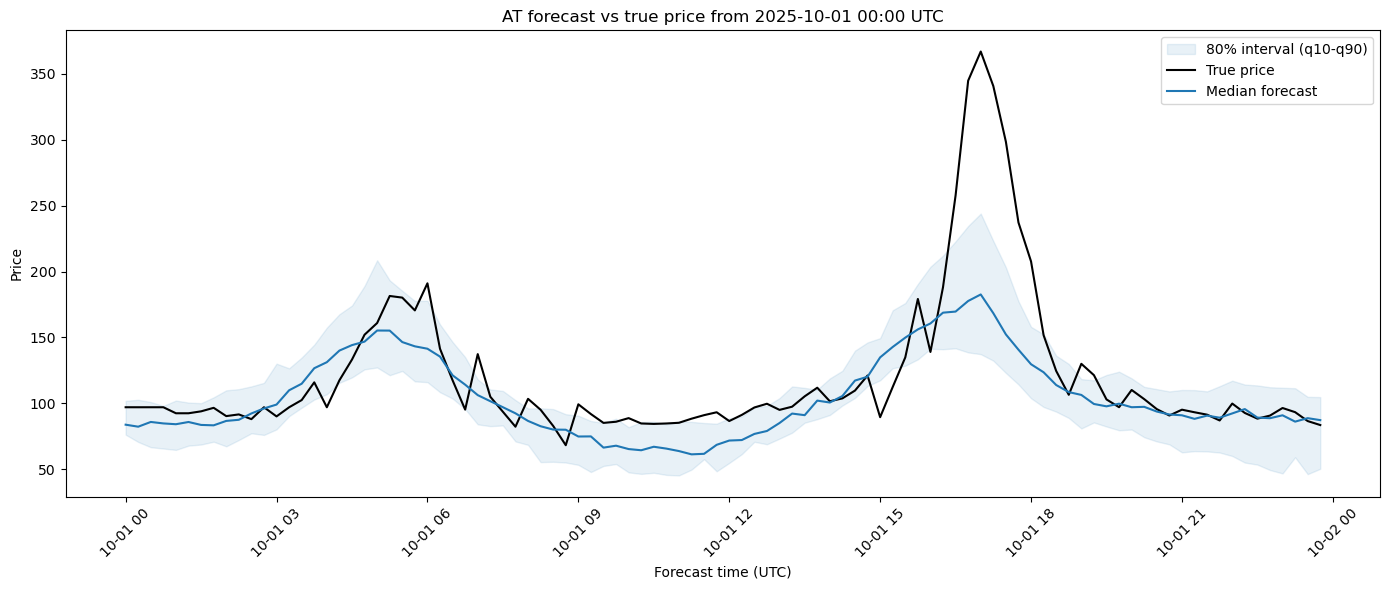

In [8]:
quantiles = [0.10, 0.50, 0.90]
forecast_result = normalize_and_forecast(
    loaded_data=loaded_data,
    phase2_model_path=phase2_model_path,
    forecast_target_country=forecast_target_country,
    forecast_graph_degree=forecast_graph_degree,
    adjacency_dict=adjacency_dict,
    input_countries=countries,
    features=features,
    lag_features=lag_features,
    lead_features=lead_features,
    label_column=label_column,
    x_scalers=x_scalers,
    y_scalers=y_scalers,
    quantiles=quantiles,
)
display(produce_testing_metrics(forecast_result, y_scalers))
display(forecast_result["forecast_df"].head())
fig, ax = visualize_forecast(forecast_result)
plt.show()

In [ ]:
#import netron
#netron.start(f"ckpt_place")

Serving 'phase1_best.keras' at http://localhost:8080


('localhost', 8080)